In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
import sys
import os
os.chdir('/content/gdrive/My Drive/HPPP/Prox_PnP/datasets/set12')

Mounted at /content/gdrive


In [2]:
import matplotlib.image as mpimg
import numpy as np

# Load the image using matplotlib
img_array = mpimg.imread('0008.png')

# Display the shape and type to confirm
print(f'Image shape: {img_array.shape}')
print(f'Data type: {img_array.dtype}')

Image shape: (481, 321, 3)
Data type: float32


In [3]:
type(img_array)

numpy.ndarray

In [4]:
img_array[40,40,1]

np.float32(0.92941177)

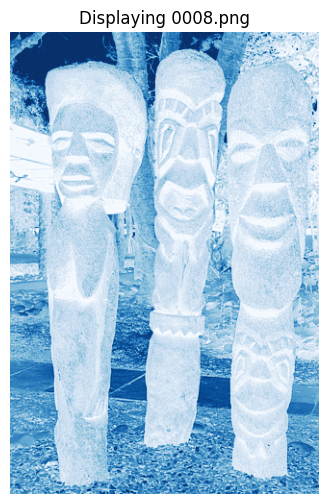

In [5]:
import matplotlib.pyplot as plt

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(img_array[:,:,0], cmap='Blues')
plt.axis('off')  # Hide grid axes
plt.title('Displaying 0008.png')
plt.show()

In [6]:
print(f'Image shape: {img_array[:,:,1].shape}')

Image shape: (481, 321)


## FFT FFT as real

In [7]:
import torch
# Convert numpy array to torch tensor
img_tensor = torch.from_numpy(img_array)

# Display the tensor shape and type
print(f'Tensor shape: {img_tensor.shape}')
print(f'Tensor type: {img_tensor.dtype}')


Tensor shape: torch.Size([481, 321, 3])
Tensor type: torch.float32


In [8]:
# Apply N-dimensional Fast Fourier Transform
img_fft = (torch.fft.fft2(img_tensor))

# Compute the magnitude spectrum for visualization
# We take the absolute value of the complex tensor
img_fft_magnitude = torch.abs(img_fft)

print(f'FFT tensor shape: {img_fft.shape}')
print(f'FFT tensor dtype: {img_fft.dtype}')
print(img_fft[150,100,0])

FFT tensor shape: torch.Size([481, 321, 3])
FFT tensor dtype: torch.complex64
tensor(-0.4925+0.6404j)


In [9]:
# Apply N-dimensional Fast Fourier Transform
img_fft = torch.view_as_real(torch.fft.fft2(img_tensor))

# Compute the magnitude spectrum for visualization
# We take the absolute value of the complex tensor
img_fft_magnitude = torch.abs(img_fft)

print(f'FFT tensor shape: {img_fft.shape}')
print(f'FFT tensor dtype: {img_fft.dtype}')
print(img_fft[150,100,0,:])

FFT tensor shape: torch.Size([481, 321, 3, 2])
FFT tensor dtype: torch.float32
tensor([-0.4925,  0.6404])


In [10]:
img_fftn = torch.view_as_real(torch.fft.fftn(img_tensor, dim=(-2,-1)))

# Compute the magnitude spectrum for visualization
# We take the absolute value of the complex tensor
img_fft_magnitude = torch.abs(img_fftn)

print(f'FFT tensor shape: {img_fftn.shape}')
print(f'FFT tensor dtype: {img_fftn.dtype}')


FFT tensor shape: torch.Size([481, 321, 3, 2])
FFT tensor dtype: torch.float32


In [11]:
img_fftn.mul(img_tensor)

RuntimeError: The size of tensor a (2) must match the size of tensor b (3) at non-singleton dimension 3